In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [11]:
# Load your preprocessed dataset
dataset = pd.read_csv("nba_preprocessed.csv")

# Features and target
X = dataset[['MP','TRB','AST','FGA','FG%','STL','TOV']]
y = dataset['PTS']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# KNN is distance-based, so scaling is essential
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
# Try k=5 neighbors as a starting point
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)


KNeighborsRegressor()

MAE: 0.236, RMSE: 0.343, R²: 0.880


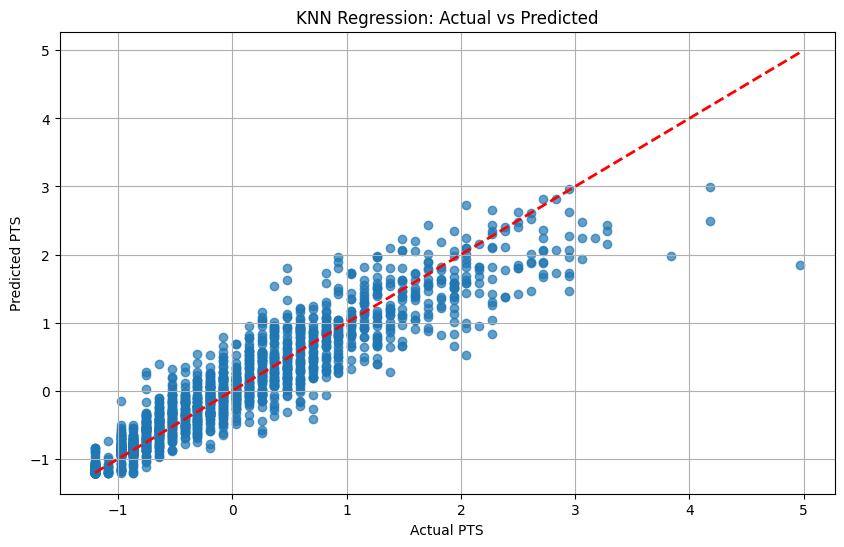

In [14]:
y_pred = knn.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")

# Plot actual vs predicted
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel("Actual PTS")
plt.ylabel("Predicted PTS")
plt.title("KNN Regression: Actual vs Predicted")
plt.grid(True)
plt.show()
